# pow benchmark — results explorer

Loads every `results/bench-*.json` written by `repro.sh` / `pow-bench --json`,
builds a per-N summary table, plots elapsed-vs-N, and overlays the theoretical
exponential distribution onto the empirical CDF for a chosen N.

This notebook is the source of truth for benchmark methodology and analysis.
The top-level README is kept as a command and file reference.


## Methodology

Let $T$ be the raw challenge token and $n$ the ASCII-decimal nonce:

$$
H(n) = \mathrm{SHA256}(T \,\|\, \mathrm{ascii}_{10}(n)).
$$

A solution for difficulty $N$ satisfies

$$
\mathrm{lzhex}(H(n)) \ge N,
$$

where $\mathrm{lzhex}$ counts leading zero hex digits in the digest. The
solver returns `(nonce, attempts, elapsed_secs, digest)`, and `verify()`
recomputes the hash independently. Both implementations use the same wire
format: raw token bytes followed by the ASCII decimal nonce.

For a uniform SHA-256 digest,

$$
p_N = 16^{-N}, \qquad \mathbb{E}[A_N] = 16^N.
$$

For hashrate $r$ hashes/s,

$$
\mathbb{E}[T_N] = \frac{16^N}{r}, \qquad
\mathrm{median}(T_N) \approx \frac{\ln 2 \cdot 16^N}{r}.
$$

For each $N$ in `[--start, --max]`, the benchmark generates a random
16-byte token and a random start nonce, solves the challenge, and records
`attempts` and wall-clock `elapsed`. Rust uses a random `u64` start nonce;
the Python baseline currently uses a random 32-bit offset. The benchmark
repeats up to `--runs` times, but stops early if cumulative wall-clock for
that $N$ exceeds the per-N budget (`max(3 × target, 30 s)`).

The headline metric is the largest $N$ whose median solve time is at most
`target_secs`. Median is used because time-to-solve is geometric in
attempts and approximately exponential in wall-clock time. Mean, p95, and
p99 are reported as diagnostics; near the target, the per-N cap often leaves
too few samples for tail estimates to be stable.


In [17]:
from __future__ import annotations

import json
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(context="notebook", style="whitegrid")


def _fmt2(v: float) -> str:
    """Two significant figures, never scientific. Keeps annotations short."""
    if v == 0 or not math.isfinite(v):
        return "0"
    digits = max(0, 1 - math.floor(math.log10(abs(v))))
    return f"{v:.{digits}f}"


# notebook lives in analysis/, results in repo_root/results/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
RESULTS_DIR = REPO_ROOT / "results"
print(f"looking for results in: {RESULTS_DIR}")

looking for results in: /Users/pikachu/dev/pow/results


In [18]:
@dataclass
class Run:
    source: str  # filename
    host: str  # hostname extracted from filename
    label: str  # host/<backend-suffix> — distinguishes implementations
    target_secs: float
    runs_per_n: int
    threads: int
    calibration: dict
    df: pd.DataFrame  # one row per (N, run_index)


def load_one(path: Path) -> Run:
    data = json.loads(path.read_text())
    # filename pattern: bench-<host>-<stamp>[-<backend>].json
    parts = path.stem.split("-") if path.stem.startswith("bench-") else []
    host = parts[1] if len(parts) > 1 else "unknown"
    backend = "-".join(parts[3:]) if len(parts) > 3 else "default"
    label = f"{host}/{backend}"
    rows = []
    for r in data["results"]:
        for i, (att, el) in enumerate(zip(r["attempts"], r["elapsed_secs"], strict=True)):
            rows.append(
                {
                    "n_zeros": r["n_zeros"],
                    "run": i,
                    "attempts": att,
                    "elapsed": el,
                    "hps": att / el if el > 0 else 0.0,
                }
            )
    return Run(
        source=path.name,
        host=host,
        label=label,
        target_secs=float(data["config"]["target_secs"]),
        runs_per_n=int(data["config"]["runs_per_n"]),
        threads=int(data["config"]["threads"]),
        calibration=data["calibration"],
        df=pd.DataFrame(rows),
    )


def discover() -> list[Run]:
    if not RESULTS_DIR.exists():
        return []
    return [load_one(p) for p in sorted(RESULTS_DIR.glob("bench-*.json"))]


runs = discover()
if not runs:
    print("No results yet. Run ./repro.sh first.")
else:
    for r in runs:
        n_min = int(r.df["n_zeros"].min())
        n_max = int(r.df["n_zeros"].max())
        print(
            f"{r.source}: label={r.label} threads={r.threads} "
            f"N={n_min}..{n_max} runs/N={r.runs_per_n}"
        )

bench-oniguruma-20260525T120719Z-shani.json: label=oniguruma/shani threads=32 N=6..9 runs/N=30
bench-oniguruma-20260525T132118Z-python.json: label=oniguruma/python threads=1 N=4..7 runs/N=30


## Per-N summary table

For each `(host, N)`, show median, p95, stddev of elapsed,
effective H/s, and how many runs landed in the bucket.


In [19]:
def summarise(runs: list[Run]) -> pd.DataFrame:
    frames = []
    for r in runs:
        g = r.df.groupby("n_zeros")
        summary = pd.DataFrame(
            {
                "runs": g.size(),
                "median_s": g["elapsed"].median(),
                "mean_s": g["elapsed"].mean(),
                "p95_s": g["elapsed"].quantile(0.95),
                "max_s": g["elapsed"].max(),
                "stddev_s": g["elapsed"].std(),
                "eff_hps": g.apply(
                    lambda x: (
                        x["attempts"].sum() / x["elapsed"].sum() if x["elapsed"].sum() > 0 else 0.0
                    )
                ),
            }
        )
        summary["label"] = r.label
        frames.append(summary.reset_index())
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    return out[
        [
            "label",
            "n_zeros",
            "runs",
            "median_s",
            "mean_s",
            "p95_s",
            "max_s",
            "stddev_s",
            "eff_hps",
        ]
    ]


summary = summarise(runs)
summary

,label,n_zeros,runs,median_s,mean_s,p95_s,max_s,stddev_s,eff_hps
0,oniguruma/shani,6,30,0.033904,0.045659,0.113626,0.175165,0.040924,3.970727e+08
1,oniguruma/shani,7,30,0.521557,0.717281,2.401757,3.349160,0.783784,3.986711e+08
2,oniguruma/shani,8,20,6.454878,10.030591,34.792611,35.891712,11.188788,4.030359e+08
3,oniguruma/shani,9,1,255.183513,255.183513,255.183513,255.183513,NaN,4.058968e+08
4,oniguruma/python,4,30,0.035587,0.056684,0.167757,0.169028,0.049310,1.327607e+06
5,oniguruma/python,5,30,0.567151,0.812808,2.140762,2.485491,0.665861,1.329816e+06
6,oniguruma/python,6,13,8.219619,14.953807,40.632078,40.911155,13.788373,1.336499e+06
7,oniguruma/python,7,5,71.888773,69.628902,156.739951,176.789441,67.921067,1.328216e+06


## Headline metric: max N fitting under target

Per host: highest N at which the **median** elapsed time stays
below `target_secs`. Median, not mean; see the methodology section above.


In [20]:
def headline(runs: list[Run]) -> pd.DataFrame:
    rows = []
    for r in runs:
        median_per_n = r.df.groupby("n_zeros")["elapsed"].median()
        passing = median_per_n[median_per_n <= r.target_secs]
        max_n = int(passing.index.max()) if not passing.empty else None
        rows.append(
            {
                "label": r.label,
                "target_s": r.target_secs,
                "max_n": max_n,
            }
        )
    return pd.DataFrame(rows)


headline(runs)

,label,target_s,max_n
0,oniguruma/shani,60.0,8
1,oniguruma/python,60.0,6


## Solve time vs difficulty

**Top.** Each run as a dot (dodged by implementation, jittered horizontally). The wide tick at each N is the median; whiskers around it are a bootstrapped 95% percentile interval — wider whisker = noisier estimate, narrows naturally as `runs` grows.

**Bottom.** Empirical median per N with a bootstrapped 95% percentile band, overlaid with the theoretical median $\ln 2 \cdot 16^N / r$ (dashed) where $r$ is the calibration hashrate appropriate to the run's parallelism. The vertical gap between dashed line and empirical points is solver overhead (rayon scope startup, atomic contention, flag polling).

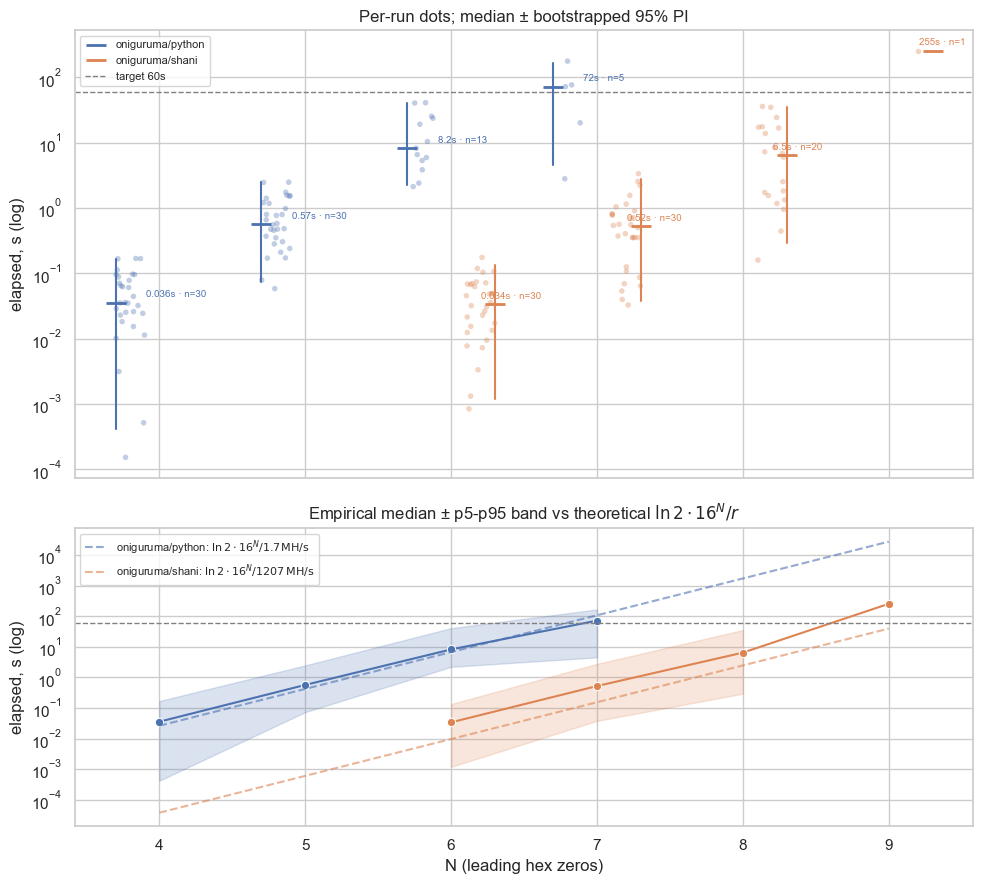

In [21]:
def _combined(runs):
    frames = []
    for r in runs:
        f = r.df.assign(label=r.label, target_secs=r.target_secs, threads=r.threads)
        f["hps_calib"] = float(r.calibration["parallel_hps" if r.threads > 1 else "single_hps"])
        frames.append(f)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


if runs:
    df_all = _combined(runs)
    order_labels = sorted(df_all["label"].unique())
    palette = dict(zip(order_labels, sns.color_palette(n_colors=len(order_labels)), strict=True))
    target_secs = runs[0].target_secs
    n_levels = sorted(int(n) for n in df_all["n_zeros"].unique())

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [3, 2]}
    )

    dodge_width = 0.6
    k = len(order_labels)

    sns.stripplot(
        data=df_all,
        x="n_zeros",
        y="elapsed",
        hue="label",
        hue_order=order_labels,
        palette=palette,
        dodge=True,
        jitter=0.2,
        alpha=0.35,
        size=4,
        native_scale=True,
        ax=ax_top,
        legend=False,
    )
    sns.pointplot(
        data=df_all,
        x="n_zeros",
        y="elapsed",
        hue="label",
        hue_order=order_labels,
        palette=palette,
        estimator="median",
        errorbar=("pi", 95),
        dodge=dodge_width,
        linestyle="none",
        markers="_",
        markersize=14,
        err_kws={"linewidth": 1.5},
        native_scale=True,
        ax=ax_top,
    )

    # Per-tick annotations: "{median}s · n={runs}". Offsets follow seaborn's
    # internal dodge formula so labels sit exactly on the tick they describe.
    for i, label in enumerate(order_labels):
        off = dodge_width * (i - (k - 1) / 2) / k
        sub = df_all[df_all["label"] == label]
        med = sub.groupby("n_zeros")["elapsed"].median()
        cnt = sub.groupby("n_zeros").size()
        for n, v in med.items():
            ax_top.annotate(
                f"{_fmt2(v)}s · n={int(cnt[n])}",
                (n + off, v),
                textcoords="offset points",
                xytext=(6, 4),
                fontsize=7,
                color=palette[label],
            )

    ax_top.axhline(
        target_secs,
        color="grey",
        linestyle="--",
        linewidth=1,
        label=f"target {target_secs:.0f}s",
    )
    ax_top.set_yscale("log")
    ax_top.set_ylabel("elapsed, s (log)")
    ax_top.set_xlabel("")
    ax_top.set_title("Per-run dots; median ± bootstrapped 95% PI")
    ax_top.legend(loc="upper left", fontsize=8)

    sns.lineplot(
        data=df_all,
        x="n_zeros",
        y="elapsed",
        hue="label",
        hue_order=order_labels,
        palette=palette,
        estimator="median",
        errorbar=("pi", 95),
        marker="o",
        ax=ax_bot,
        legend=False,
    )
    ns_smooth = np.linspace(min(n_levels), max(n_levels), 100)
    ln2 = np.log(2)
    for label in order_labels:
        hps = df_all.loc[df_all["label"] == label, "hps_calib"].iloc[0]
        ax_bot.plot(
            ns_smooth,
            ln2 * (16**ns_smooth) / hps,
            color=palette[label],
            linewidth=1.5,
            linestyle="--",
            alpha=0.6,
            label=rf"{label}: $\ln 2 \cdot 16^N / {_fmt2(hps / 1e6)}\,\mathrm{{MH/s}}$",
        )
    ax_bot.axhline(target_secs, color="grey", linestyle="--", linewidth=1)
    ax_bot.set_yscale("log")
    ax_bot.set_xlabel("N (leading hex zeros)")
    ax_bot.set_ylabel("elapsed, s (log)")
    ax_bot.set_title(r"Empirical median ± p5-p95 band vs theoretical $\ln 2 \cdot 16^N / r$")
    ax_bot.legend(loc="upper left", fontsize=8)
    ax_bot.set_xticks(n_levels)

    plt.tight_layout()
    plt.show()
else:
    print("no data — run ./repro.sh")

## Empirical vs theoretical distribution at a fixed N

Time-to-solve is geometric in attempts and approximately exponential in wall-clock, with rate $\lambda = r / 16^N$. The cell below picks the largest N where some implementation has $\ge 10$ runs and overlays the empirical ECDFs of all implementations available at that N onto their respective theoretical $\mathrm{Exp}(\lambda)$ CDFs. Systematic deviation between empirical (step) and theoretical (dashed) lines points to coordination cost or hashrate inconsistency.

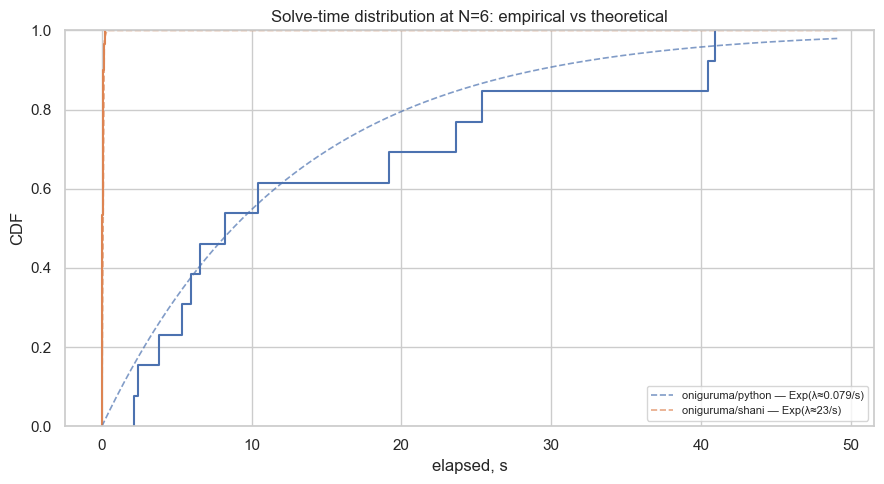

In [22]:
def _best_shared_n(runs, min_runs: int = 10) -> int | None:
    """Pick N where the most implementations have >= min_runs samples; tiebreak by larger N."""
    counts = (
        pd.concat([r.df.assign(label=r.label) for r in runs]).groupby(["label", "n_zeros"]).size()
    )
    by_n: dict[int, int] = {}
    for (_, n), c in counts.items():
        if c >= min_runs:
            by_n[int(n)] = by_n.get(int(n), 0) + 1
    if not by_n:
        return None
    max_share = max(by_n.values())
    return max(n for n, c in by_n.items() if c == max_share)


def plot_ecdf_at(runs, n: int) -> None:
    rows = []
    for r in runs:
        sub = r.df[r.df["n_zeros"] == n]
        if len(sub) < 2:
            continue
        rows.append(sub.assign(label=r.label))
    if not rows:
        print(f"no implementation has enough samples at N={n}")
        return
    df_n = pd.concat(rows, ignore_index=True)
    labels = sorted(df_n["label"].unique())
    palette = dict(zip(labels, sns.color_palette(n_colors=len(labels)), strict=True))

    _fig, ax = plt.subplots(figsize=(9, 5))
    sns.ecdfplot(
        data=df_n,
        x="elapsed",
        hue="label",
        hue_order=labels,
        palette=palette,
        ax=ax,
    )
    t_max = df_n["elapsed"].max() * 1.2
    ts = np.linspace(0, t_max, 300)
    for label in labels:
        sub = df_n[df_n["label"] == label]
        rate = sub["hps"].mean() / (16**n)
        ax.plot(
            ts,
            stats.expon.cdf(ts, scale=1.0 / rate),
            color=palette[label],
            linestyle="--",
            linewidth=1.2,
            alpha=0.7,
            label=f"{label} — Exp(λ≈{_fmt2(rate)}/s)",
        )
    ax.set_xlabel("elapsed, s")
    ax.set_ylabel("CDF")
    ax.set_title(f"Solve-time distribution at N={n}: empirical vs theoretical")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


if runs:
    n = _best_shared_n(runs)
    if n is not None:
        plot_ecdf_at(runs, n)
    else:
        print("no implementation has >= 10 runs at any N")

## Density view (diagnostic)

ECDFs can hide deviations; the density view is sharper. For the same N as the ECDF above, this cell shows a histogram of solve times per implementation with the theoretical $\mathrm{Exp}(\lambda)$ density overlaid. Heavy right tails, bimodality, or systematic mass concentration vs the exponential curve all surface here before they would in the cumulative view.

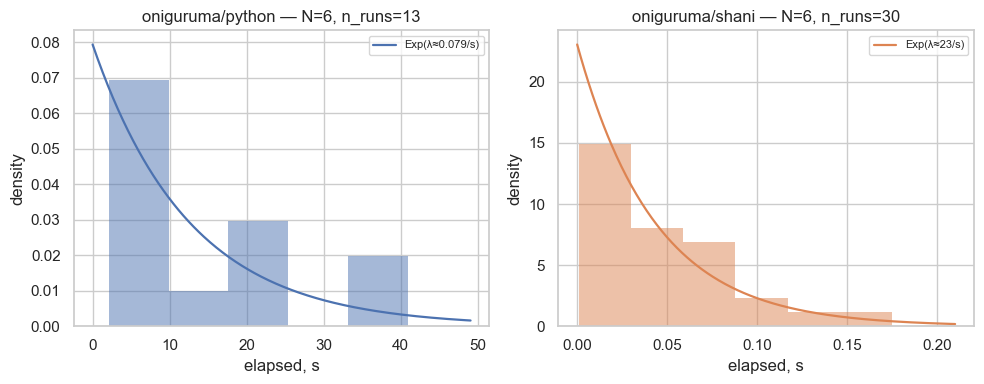

In [23]:
def plot_pdf_at(runs, n: int) -> None:
    rows = []
    for r in runs:
        sub = r.df[r.df["n_zeros"] == n]
        if len(sub) < 5:
            continue
        rows.append(sub.assign(label=r.label))
    if not rows:
        print(f"no implementation has enough samples at N={n}")
        return
    df_n = pd.concat(rows, ignore_index=True)
    labels = sorted(df_n["label"].unique())
    palette = dict(zip(labels, sns.color_palette(n_colors=len(labels)), strict=True))

    _fig, axes = plt.subplots(1, len(labels), figsize=(5 * len(labels), 4), sharey=False)
    if len(labels) == 1:
        axes = [axes]
    for ax, label in zip(axes, labels, strict=True):
        sub = df_n[df_n["label"] == label]
        sns.histplot(
            sub["elapsed"],
            bins="auto",
            stat="density",
            color=palette[label],
            ax=ax,
            alpha=0.5,
            edgecolor="none",
        )
        rate = sub["hps"].mean() / (16**n)
        ts = np.linspace(1e-9, sub["elapsed"].max() * 1.2, 300)
        ax.plot(
            ts,
            stats.expon.pdf(ts, scale=1.0 / rate),
            color=palette[label],
            linewidth=1.6,
            label=f"Exp(λ≈{_fmt2(rate)}/s)",
        )
        ax.set_title(f"{label} — N={n}, n_runs={len(sub)}")
        ax.set_xlabel("elapsed, s")
        ax.set_ylabel("density")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


if runs:
    n = _best_shared_n(runs)
    if n is not None:
        plot_pdf_at(runs, n)

## Host comparison matrix

Pivot of median-elapsed by N and host. Ratios make cross-machine comparisons
easy when several result files are present.


In [24]:
if runs:
    pivot = summarise(runs).pivot_table(index="n_zeros", columns="label", values="median_s")
    display(pivot)
    if pivot.shape[1] >= 2:
        baseline = pivot.iloc[:, 0]
        ratios = pivot.div(baseline, axis=0)
        print(f"speedup vs {pivot.columns[0]} (lower = faster):")
        display(ratios)

label,oniguruma/python,oniguruma/shani
n_zeros,,
4,0.035587,NaN
5,0.567151,NaN
6,8.219619,0.033904
7,71.888773,0.521557
8,NaN,6.454878
9,NaN,255.183513


speedup vs oniguruma/python (lower = faster):


label,oniguruma/python,oniguruma/shani
n_zeros,,
4,1.0,NaN
5,1.0,NaN
6,1.0,0.004125
7,1.0,0.007255
8,NaN,NaN
9,NaN,NaN
